# Low-till Ratios in the U.S. Corn Belt: Fig 1(b)
# Field Identification: Fig 2(b)-(c)


In [1]:
import pandas as pd
from sklearn.metrics import r2_score, accuracy_score, classification_report

import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.metrics import confusion_matrix

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
states = ['IA', 'MN', 'IL', 'IN',  'KS', 'MI', 'MO', 'NE', 'OH',  'ND', 'SD', 'WI']
states = ['IA', 'MN', 'IL', 'IN',  'MI', 'MO', 'OH',  'SD', 'WI']
years = np.arange(1999, 2024)

In [3]:
import os
cofi_list = []

for state in states:
    for year in years:

        model_proportion = ''
        model_type = "STAPL" #+ str(year) #+ model_proportion

        filename = "../../data/STAPL_county_ratio_filled_all/" + state + "_" + str(year) + "_" + model_type + ".csv"
        # Skip if file does not exist
        if not os.path.exists(filename):
            print(f"File not found: {filename}, skipping...")
            continue

        df_cofi_year = pd.read_csv(filename)
        df_cofi_year['year'] = year

        cofi_list.append(df_cofi_year)

cofi_all = pd.concat(cofi_list)
cofi_all = cofi_all.rename(columns={'GEOID':'FIPS'})
cofi_all['state'] = cofi_all['FIPS'] // 1000

In [4]:
cofi_all['low-till'] = cofi_all['class_1'] / (cofi_all['class_0'] + cofi_all['class_1']) 
cofi_all['pixel_low_till'] = (cofi_all['class_0'] + cofi_all['class_1']) * 900 * 0.000247105 # m2 to acres
cofi_all = cofi_all.dropna()
print(cofi_all.shape)

(18972, 7)


In [5]:
cofi_state = cofi_all.copy()
cofi_state = cofi_state.groupby(['state', 'year']).sum().reset_index()

In [6]:
cofi_state = cofi_state[['state', 'year', 'class_0', 'class_1']]
cofi_state['low-till'] = cofi_state['class_1'] / (cofi_state['class_0'] + cofi_state['class_1'])

In [7]:
list_year = []
for year in years:

    cofi_all_year = cofi_all[cofi_all['year'] == year]
    list_year.append(np.mean(cofi_all_year['low-till']))


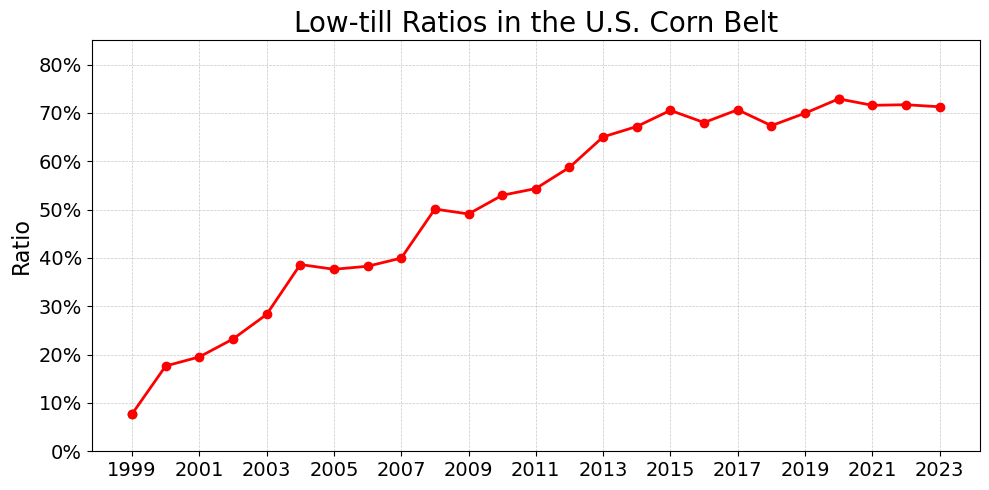

In [8]:
plt.figure(figsize=(10, 5))
data = list_year

plt.plot(years, data, marker='o', linestyle='-', linewidth=2,
         markersize=6, color='red')

# Grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Max / Min points
max_idx = np.argmax(data)
min_idx = np.argmin(data)
plt.scatter(years[max_idx], data[max_idx], color='red', label='Max Area')
plt.scatter(years[min_idx], data[min_idx], color='green', label='Min Area')

# Labels
plt.title('Low-till Ratios in the U.S. Corn Belt', fontsize=20)
plt.ylabel('Ratio', fontsize=16)
#plt.xlabel('Years', fontsize=14)

# ---- Key change here ----
# create ticks every 5 years
xticks_5yr = np.arange(min(years), max(years) + 1, 2)
plt.xticks(xticks_5yr, rotation=0, fontsize=14)
yticks = np.arange(0.0, 0.9, 0.1)
plt.yticks(yticks, [f"{int(y*100)}%" for y in yticks], fontsize=14)
# ------------------------

plt.ylim([0.00, 0.85])

plt.tight_layout()
plt.show()

## Representative Fields

In [11]:
from pathlib import Path
import pandas as pd

#field_ids = [7122927, 7126539, 7130792, 7129049, 7128026, 7123343]
field_ids = [7122927, 7130792, 7128026]

corn_path = Path(
    "../../data/Field_yield_tillage/processed_smooth_1999_2023/corn_yield_tillage_IL_1999_2023.csv"
)

corn_examples = pd.read_csv(
    corn_path,
    usecols=[
        "OBJECTID", "year", "yield", "size", "GEOID", "till",
        "till_1_count", "till_1_streak", "till_0_count", "till_0_streak"
    ],
)

corn_examples = corn_examples[corn_examples["OBJECTID"].isin(field_ids)].copy()


corn_examples


,OBJECTID,yield,size,year,till,GEOID,till_1_count,till_1_streak,till_0_count,till_0_streak
180410,7128026,11239,559,1999,0,17075,0,0,1,1
183819,7130792,10020,1044,1999,0,17075,0,0,1,1
207872,7122927,7724,204,1999,0,17075,0,0,1,1
541829,7128026,11815,299,2000,0,17075,0,0,2,2
545293,7130792,10801,1201,2000,0,17075,0,0,2,2
...,...,...,...,...,...,...,...,...,...,...
8057184,7130792,14581,2231,2022,1,17075,11,10,13,0
8081256,7122927,13163,327,2022,1,17075,1,1,23,0
8360847,7128026,14841,245,2023,0,17075,21,0,4,1
8363910,7130792,14044,45,2023,0,17075,11,0,14,1


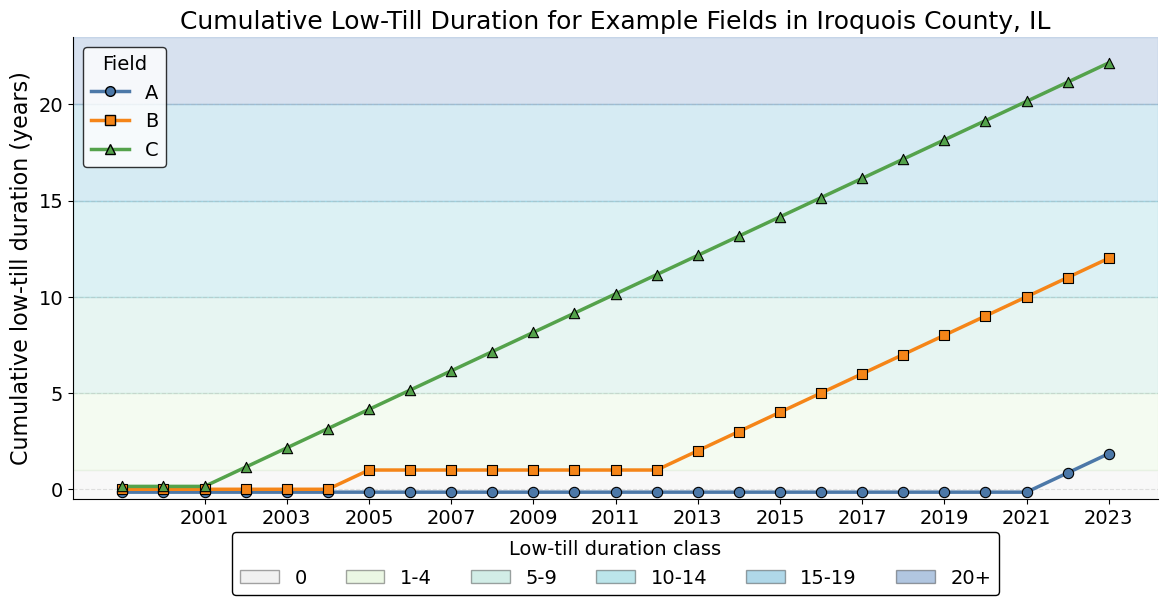

In [12]:
# Optional: prettier names for the fields
field_display_labels = {
    7122927: "A",
    7130792: "B",
    7128026: "C",
}

field_markers = {
    7122927: "o",
    7130792: "s",
    7128026: "^",
}

field_colors = {
    7122927: "#4C78A8",  # muted blue
    7130792: "#F58518",  # muted orange
    7128026: "#54A24B",  # muted green
}

field_order = [7122927, 7130792, 7128026]
field_order_labels = [field_display_labels[i] for i in field_order]
year_order = list(range(1999, 2024))

plot_df = corn_examples.copy()
plot_df["field_label"] = plot_df["OBJECTID"].map(field_display_labels)

# Build field x year matrices
till_matrix = (
    plot_df.pivot_table(
        index="field_label",
        columns="year",
        values="till",
        aggfunc="first",
    )
    .reindex(index=field_order_labels)
    .reindex(columns=year_order)
)

streak_matrix = (
    plot_df.pivot_table(
        index="field_label",
        columns="year",
        values="till_1_count",
        aggfunc="first",
    )
    .reindex(index=field_order_labels)
    .reindex(columns=year_order)
)

# Fill missing records as conventional
till_matrix = till_matrix.fillna(0).astype(int)
streak_matrix = streak_matrix.fillna(0).astype(float)

# Fill one-year gaps and extend the last year if needed
for idx in till_matrix.index:
    till_vals = till_matrix.loc[idx].to_numpy().copy()
    streak_vals = streak_matrix.loc[idx].to_numpy().copy()

    for j in range(1, len(till_vals) - 1):
        if till_vals[j] == 0 and till_vals[j - 1] == 1 and till_vals[j + 1] == 1:
            till_vals[j] = 1

            prev_streak = streak_vals[j - 1]
            next_streak = streak_vals[j + 1]

            if prev_streak > 0 and next_streak > 0:
                streak_vals[j] = prev_streak + 1
            else:
                streak_vals[j] = 1

    if len(till_vals) >= 2 and till_vals[-1] == 0 and till_vals[-2] == 1:
        till_vals[-1] = 1
        if streak_vals[-2] > 0:
            streak_vals[-1] = streak_vals[-2] + 1
        else:
            streak_vals[-1] = 1

    till_matrix.loc[idx] = till_vals
    streak_matrix.loc[idx] = streak_vals

field_offsets = {
    7122927: -0.15,
    7130792:  0.00,
    7128026:  0.15,
}

fig, ax = plt.subplots(figsize=(14, 7))

# Horizontal shaded bands for duration classes
band_specs = [
    (-0.5, 1,  "#d9d9d9", "0"),
    (1, 5,   "#c7e9b4", "1-4"),
    (5, 10,   "#7fcdbb", "5-9"),
    (10, 15,  "#41b6c4", "10-14"),
    (15, 20, "#1d91c0", "15-19"),
    (20, 23.5, "#225ea8", "20+"),
]

for y0, y1, color, _ in band_specs:
    ax.axhspan(y0, y1, color=color, alpha=0.18, zorder=0)

# Plot each field using actual low-till duration years
for objectid in field_order:
    field_label = field_display_labels[objectid]
    y = streak_matrix.loc[field_label].to_numpy(dtype=float)
    y_plot = y + field_offsets[objectid]

    ax.plot(
        year_order,
        y_plot,
        color=field_colors[objectid],
        linewidth=2.5,
        zorder=2,
    )

    ax.scatter(
        year_order,
        y_plot,
        s=55,
        color=field_colors[objectid],
        marker=field_markers[objectid],
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
        label=field_label,
    )

ax.set_title(
    "Cumulative Low-Till Duration for Example Fields in Iroquois County, IL",
    fontsize=18,
)
ax.set_ylabel("Cumulative low-till duration (years)", fontsize=16)

ax.set_xticks(list(range(2001, 2024, 2)))
ax.tick_params(axis="x", rotation=0, labelsize=14)
ax.tick_params(axis="y", rotation=0, labelsize=14)

ax.set_ylim(-0.5, 23.5)
ax.set_yticks([0, 5, 10, 15, 20])
ax.grid(axis="y", linestyle="--", alpha=0.35)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend for fields
field_handles = [
    Line2D(
        [0], [0],
        color=field_colors[i],
        marker=field_markers[i],
        lw=2.5,
        markersize=7,
        markeredgecolor="black",
        label=field_display_labels[i],
    )
    for i in field_order
]

# Legend for duration-class bands
band_handles = [
    Patch(facecolor=color, edgecolor="black", alpha=0.35, label=label)
    for _, _, color, label in band_specs
]

legend1 = ax.legend(
    handles=field_handles,
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=14,
    title="Field",
    title_fontsize=14,
)
ax.add_artist(legend1)

ax.legend(
    handles=band_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=6,
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1,
    fontsize=14,
    title="Low-till duration class",
    title_fontsize=14,
)

plt.subplots_adjust(bottom=0.22)
plt.show()

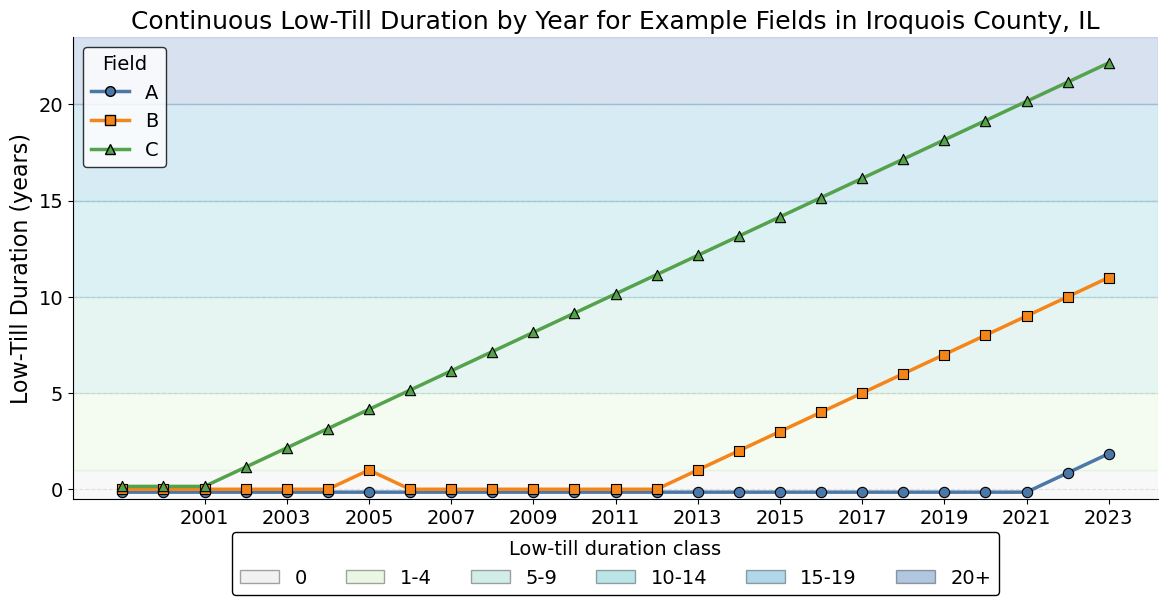

In [13]:
# Optional: prettier names for the fields
field_display_labels = {
    7122927: "A",
    7130792: "B",
    7128026: "C",
}

field_markers = {
    7122927: "o",
    7130792: "s",
    7128026: "^",
}

field_colors = {
    7122927: "#4C78A8",  # muted blue
    7130792: "#F58518",  # muted orange
    7128026: "#54A24B",  # muted green
}

field_order = [7122927, 7130792, 7128026]
field_order_labels = [field_display_labels[i] for i in field_order]
year_order = list(range(1999, 2024))

plot_df = corn_examples.copy()
plot_df["field_label"] = plot_df["OBJECTID"].map(field_display_labels)

# Build field x year matrices
till_matrix = (
    plot_df.pivot_table(
        index="field_label",
        columns="year",
        values="till",
        aggfunc="first",
    )
    .reindex(index=field_order_labels)
    .reindex(columns=year_order)
)

streak_matrix = (
    plot_df.pivot_table(
        index="field_label",
        columns="year",
        values="till_1_streak",
        aggfunc="first",
    )
    .reindex(index=field_order_labels)
    .reindex(columns=year_order)
)

# Fill missing records as conventional
till_matrix = till_matrix.fillna(0).astype(int)
streak_matrix = streak_matrix.fillna(0).astype(float)

# Fill one-year gaps and extend the last year if needed
for idx in till_matrix.index:
    till_vals = till_matrix.loc[idx].to_numpy().copy()
    streak_vals = streak_matrix.loc[idx].to_numpy().copy()

    for j in range(1, len(till_vals) - 1):
        if till_vals[j] == 0 and till_vals[j - 1] == 1 and till_vals[j + 1] == 1:
            till_vals[j] = 1

            prev_streak = streak_vals[j - 1]
            next_streak = streak_vals[j + 1]

            if prev_streak > 0 and next_streak > 0:
                streak_vals[j] = prev_streak + 1
            else:
                streak_vals[j] = 1

    if len(till_vals) >= 2 and till_vals[-1] == 0 and till_vals[-2] == 1:
        till_vals[-1] = 1
        if streak_vals[-2] > 0:
            streak_vals[-1] = streak_vals[-2] + 1
        else:
            streak_vals[-1] = 1

    till_matrix.loc[idx] = till_vals
    streak_matrix.loc[idx] = streak_vals

field_offsets = {
    7122927: -0.15,
    7130792:  0.00,
    7128026:  0.15,
}

fig, ax = plt.subplots(figsize=(14, 7))

# Horizontal shaded bands for duration classes
band_specs = [
    (-0.5, 1,  "#d9d9d9", "0"),
    (1, 5,   "#c7e9b4", "1-4"),
    (5, 10,   "#7fcdbb", "5-9"),
    (10, 15,  "#41b6c4", "10-14"),
    (15, 20, "#1d91c0", "15-19"),
    (20, 23.5, "#225ea8", "20+"),
]

for y0, y1, color, _ in band_specs:
    ax.axhspan(y0, y1, color=color, alpha=0.18, zorder=0)

# Plot each field using actual low-till duration years
for objectid in field_order:
    field_label = field_display_labels[objectid]
    y = streak_matrix.loc[field_label].to_numpy(dtype=float)
    y_plot = y + field_offsets[objectid]

    ax.plot(
        year_order,
        y_plot,
        color=field_colors[objectid],
        linewidth=2.5,
        zorder=2,
    )

    ax.scatter(
        year_order,
        y_plot,
        s=55,
        color=field_colors[objectid],
        marker=field_markers[objectid],
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
        label=field_label,
    )

ax.set_title(
    "Continuous Low-Till Duration by Year for Example Fields in Iroquois County, IL",
    fontsize=18,
)
ax.set_ylabel("Low-Till Duration (years)", fontsize=16)

ax.set_xticks(list(range(2001, 2024, 2)))
ax.tick_params(axis="x", rotation=0, labelsize=14)
ax.tick_params(axis="y", rotation=0, labelsize=14)

ax.set_ylim(-0.5, 23.5)
ax.set_yticks([0, 5, 10, 15, 20])
ax.grid(axis="y", linestyle="--", alpha=0.35)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend for fields
field_handles = [
    Line2D(
        [0], [0],
        color=field_colors[i],
        marker=field_markers[i],
        lw=2.5,
        markersize=7,
        markeredgecolor="black",
        label=field_display_labels[i],
    )
    for i in field_order
]

# Legend for duration-class bands
band_handles = [
    Patch(facecolor=color, edgecolor="black", alpha=0.35, label=label)
    for _, _, color, label in band_specs
]

legend1 = ax.legend(
    handles=field_handles,
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=14,
    title="Field",
    title_fontsize=14,
)
ax.add_artist(legend1)

ax.legend(
    handles=band_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=6,
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1,
    fontsize=14,
    title="Low-till duration class",
    title_fontsize=14,
)

plt.subplots_adjust(bottom=0.22)
plt.show()

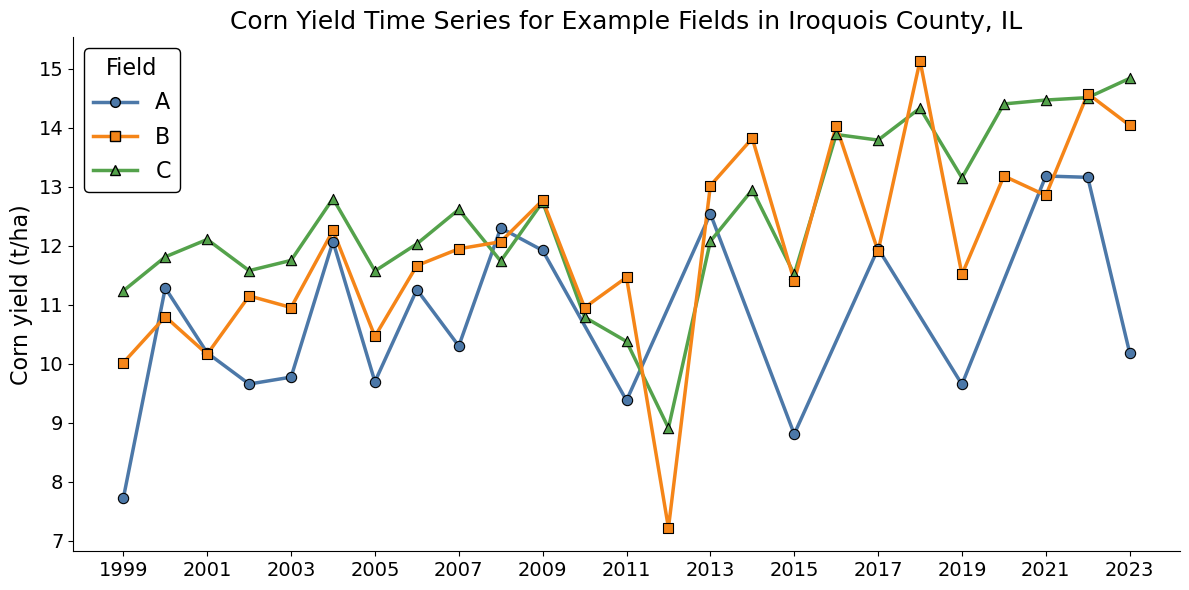

In [14]:
field_colors = {
    7122927: "#4C78A8",  # muted blue
    7130792: "#F58518",  # muted orange
    7128026: "#54A24B",  # muted green
}

plot_df = corn_examples.copy().sort_values(["OBJECTID", "year"])

fig, ax = plt.subplots(figsize=(12, 6))

for objectid, g in plot_df.groupby("OBJECTID", sort=False):
    g = g.sort_values("year")

    x = g["year"].to_numpy()
    y = g["yield"].to_numpy() / 1000

    ax.plot(
        x,
        y,
        color=field_colors[objectid],
        linewidth=2.5,
        zorder=2,
    )

    ax.scatter(
        x,
        y,
        color=field_colors[objectid],
        s=55,
        marker=field_markers[objectid],
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
    )

ax.set_title(
    "Corn Yield Time Series for Example Fields in Iroquois County, IL",
    fontsize=18,
)
ax.set_ylabel("Corn yield (t/ha)", fontsize=16)
ax.set_xticks(list(range(1999, 2024, 2)))
ax.tick_params(axis="x", rotation=0, labelsize=14)
ax.tick_params(axis="y", rotation=0, labelsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_handles = [
    Line2D(
        [0],
        [0],
        color=field_colors[objectid],
        lw=2.5,
        marker=field_markers[objectid],
        markersize=7,
        markeredgecolor="black",
        label=field_display_labels[objectid],
    )
    for objectid in field_order
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1,
    fontsize=16,
    title="Field",
    title_fontsize=16,
)

plt.tight_layout()
plt.show()